In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, permutation_test_score, cross_val_predict
from sklearn.metrics import (make_scorer, f1_score, precision_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
                             classification_report)
from sklearn.inspection import permutation_importance

Total samples: 61  |  Binders: 37  |  Nonbinders: 24

--- Fold composition (n_splits=7) ---
  Fold 1: train = 31 binders / 21 nonbinders  |  test = 6 binders / 3 nonbinders
  Fold 2: train = 31 binders / 21 nonbinders  |  test = 6 binders / 3 nonbinders
  Fold 3: train = 32 binders / 20 nonbinders  |  test = 5 binders / 4 nonbinders
  Fold 4: train = 32 binders / 20 nonbinders  |  test = 5 binders / 4 nonbinders
  Fold 5: train = 32 binders / 20 nonbinders  |  test = 5 binders / 4 nonbinders
  Fold 6: train = 32 binders / 21 nonbinders  |  test = 5 binders / 3 nonbinders
  Fold 7: train = 32 binders / 21 nonbinders  |  test = 5 binders / 3 nonbinders

--- 7-fold stratified CV (balanced RF) ---
                    Mean     SD
accuracy           0.819  0.145
balanced_accuracy  0.785  0.165
roc_auc            0.810  0.218
f1                 0.859  0.115
precision          0.838  0.157
recall             0.914  0.146

Permutation test  |  Observed balanced accuracy: 0.785  |  p-value: 0.01

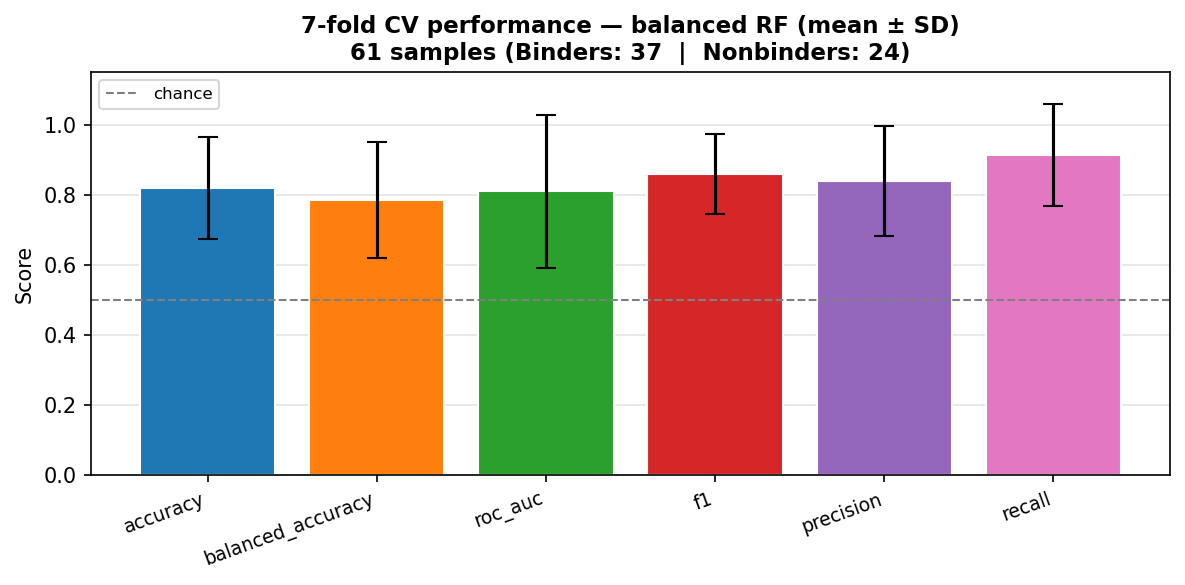

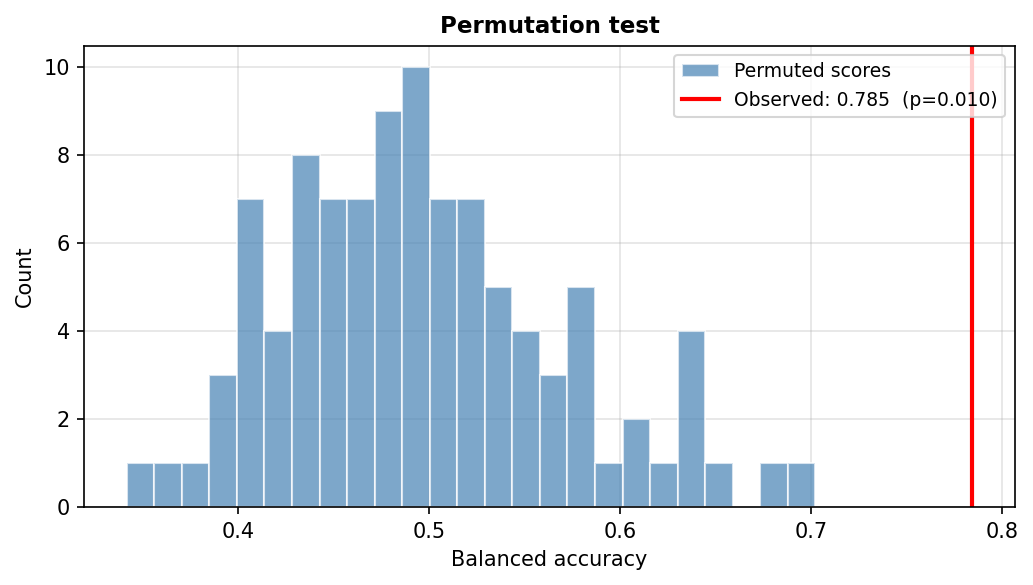

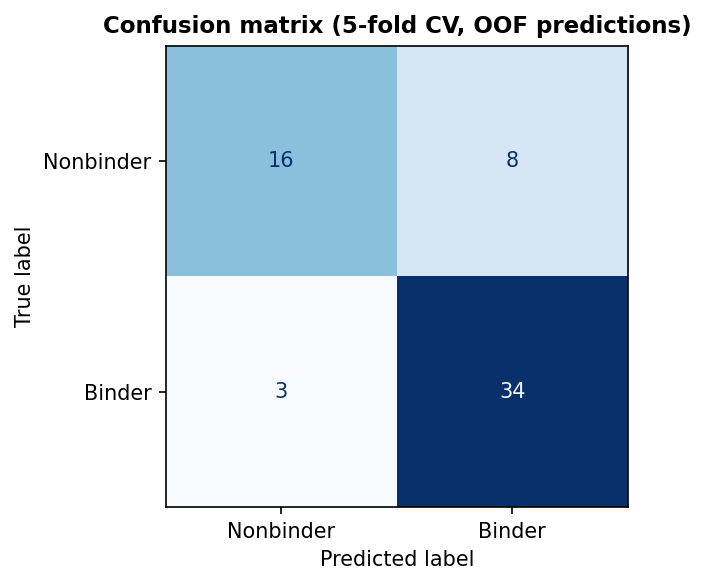

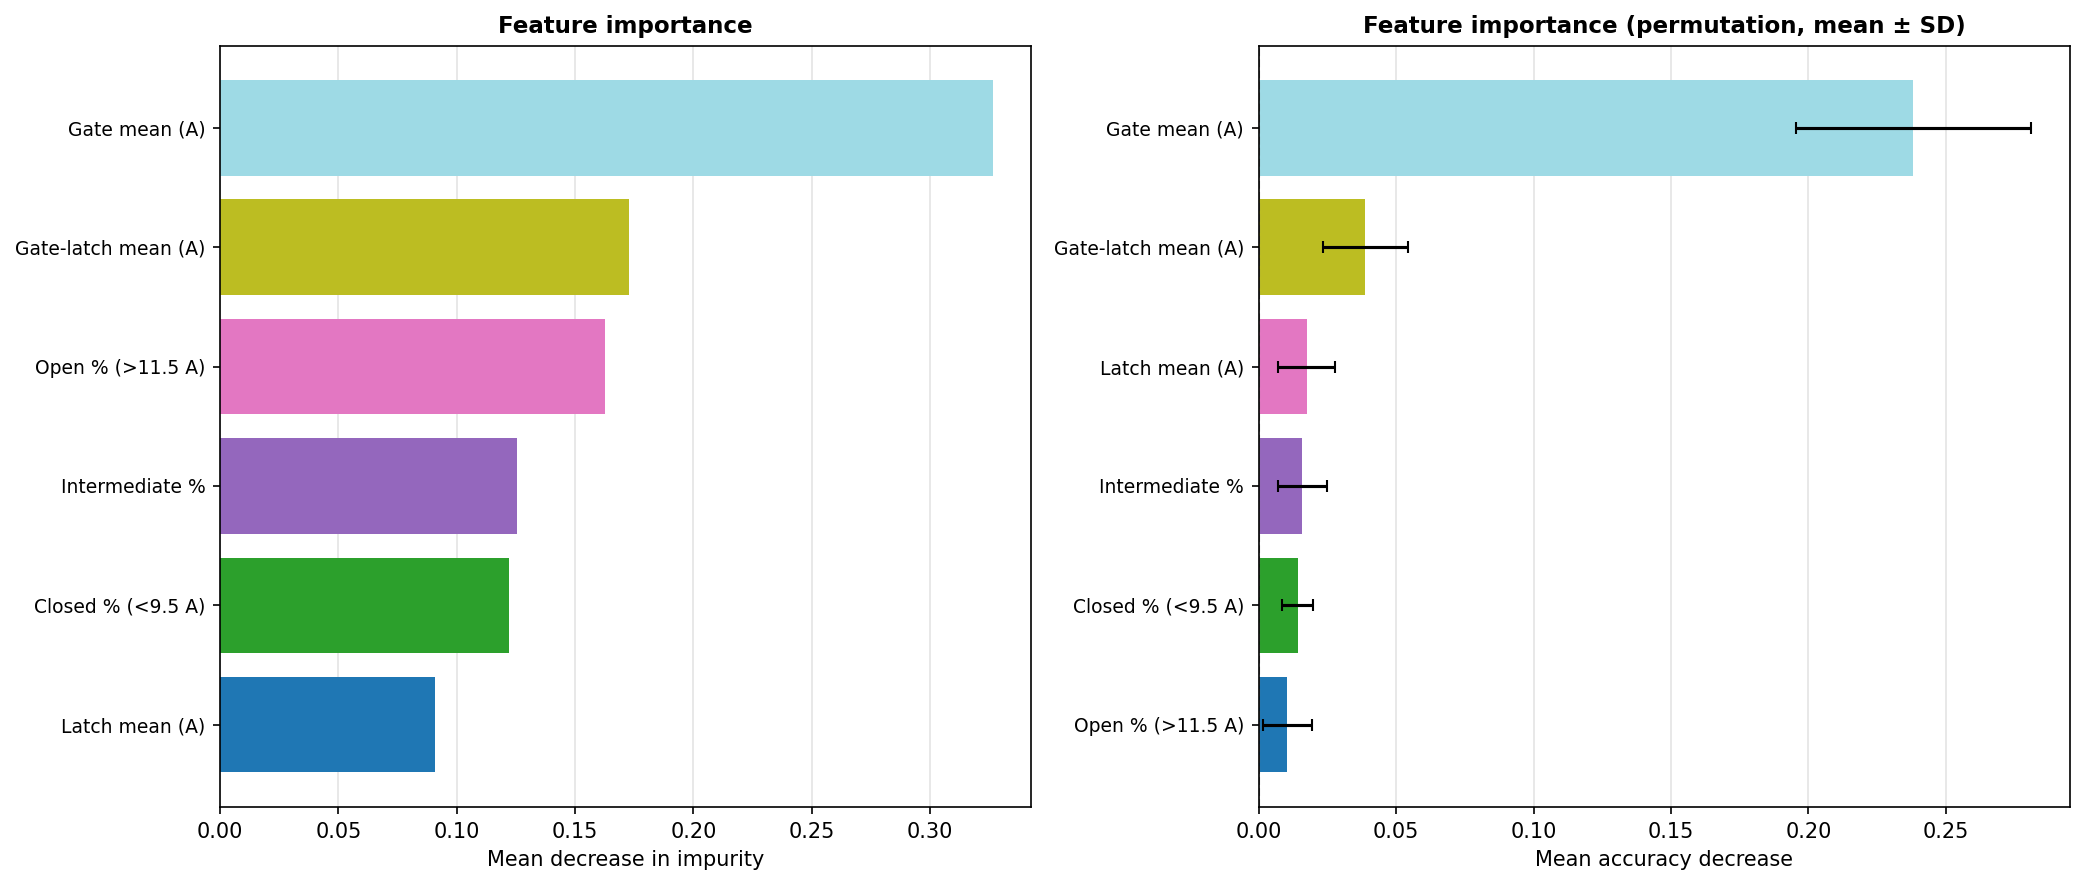

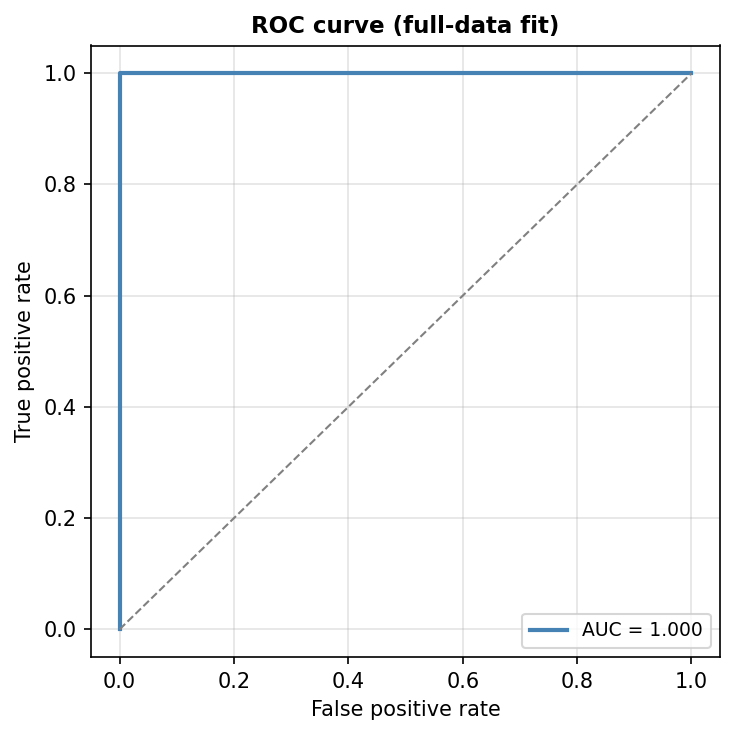


--- Classification report (5-fold CV, OOF predictions) ---
              precision    recall  f1-score   support

   Nonbinder       0.84      0.67      0.74        24
      Binder       0.81      0.92      0.86        37

    accuracy                           0.82        61
   macro avg       0.83      0.79      0.80        61
weighted avg       0.82      0.82      0.81        61



In [9]:
# -------------------------------------------------------------------
# Load feature matrix
# -------------------------------------------------------------------
df = pd.read_excel(
    "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/feat_table.xlsx", sheet_name='Sheet2',
    index_col="ID"
)

# -------------------------------------------------------------------
# Features and labels
# -------------------------------------------------------------------
feature_cols = [
    "Gate mean (A)",
    "Latch mean (A)",
    "Gate-latch mean (A)",
    "Closed % (<9.5 A)",   "Open % (>11.5 A)", "Intermediate %",
]

# feature_cols = [
#     "Gate mean (A)",       "Gate SD (A)",
#     "Latch mean (A)",      "Latch SD (A)",
#     "Lb7a5 mean (A)",      "Lb7a5 SD (A)",
#     "Recoil mean (A)",     "Recoil SD (A)",
#     "Gate-latch mean (A)", "Gate-latch SD (A)",
#     "Closed % (<9.5 A)",   "Open % (>11.5 A)", "Intermediate %",
# ]

X = df[feature_cols].values
y = df["Label"].values

n_binders    = y.sum()
n_nonbinders = (y == 0).sum()
print(f"Total samples: {len(y)}  |  Binders: {n_binders}  |  Nonbinders: {n_nonbinders}")

# -------------------------------------------------------------------
N_SPLITS = 7
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

print(f"\n--- Fold composition (n_splits={N_SPLITS}) ---")
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y)):
    n_b_train  = y[train_idx].sum()
    n_b_test   = y[test_idx].sum()
    n_nb_train = (y[train_idx] == 0).sum()
    n_nb_test  = (y[test_idx]  == 0).sum()
    print(f"  Fold {fold+1}: train = {n_b_train} binders / {n_nb_train} nonbinders  |  "
          f"test = {n_b_test} binders / {n_nb_test} nonbinders")


rf = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
)

# -------------------------------------------------------------------
# Stratified cross-validation
# -------------------------------------------------------------------
scoring = {
    "accuracy":          "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc":           "roc_auc",
    "f1":                make_scorer(f1_score,        zero_division=0),
    "precision":         make_scorer(precision_score, zero_division=0),
    "recall":            make_scorer(recall_score,    zero_division=0),
}

cv_results = cross_validate(
    rf, X, y, cv=cv,
    scoring=scoring,
    return_train_score=False,
)

metrics = {k.replace("test_", ""): v for k, v in cv_results.items()
           if k.startswith("test_")}

print(f"\n--- {N_SPLITS}-fold stratified CV (balanced RF) ---")
metrics_df = pd.DataFrame({
    k: {"Mean": round(v.mean(), 3), "SD": round(v.std(), 3)}
    for k, v in metrics.items()
}).T
print(metrics_df.to_string())

# -------------------------------------------------------------------
# Permutation test
# -------------------------------------------------------------------
score, perm_scores, pval = permutation_test_score(
    rf, X, y, cv=cv, scoring="balanced_accuracy",
    n_permutations=100, random_state=42, n_jobs=1,
)
print(f"\nPermutation test  |  Observed balanced accuracy: {score:.3f}  |  p-value: {pval:.3f}")

# -------------------------------------------------------------------
# Fit on full dataset for importance
# -------------------------------------------------------------------
rf.fit(X, y)
y_pred = rf.predict(X)
y_prob = rf.predict_proba(X)[:, 1]

# -------------------------------------------------------------------
# Figure 1: CV metric summary
# -------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(8, 4), dpi=150)
metric_names = list(metrics.keys())
means = [metrics[m].mean() for m in metric_names]
sds   = [metrics[m].std()  for m in metric_names]
x     = np.arange(len(metric_names))

ax1.bar(x, means, yerr=sds, capsize=5,
        color=plt.get_cmap("tab10")(np.linspace(0, 0.6, len(metric_names))),
        edgecolor="white")
ax1.set_xticks(x)
ax1.set_xticklabels(metric_names, rotation=20, ha="right", fontsize=9)
ax1.set_ylabel("Score", fontsize=10)
ax1.set_ylim(0, 1.15)
ax1.axhline(0.5, color="gray", linestyle="--", lw=1, label="chance")
ax1.set_title(f"{N_SPLITS}-fold CV performance — balanced RF (mean ± SD)\n{len(y)} samples (Binders: {n_binders}  |  Nonbinders: {n_nonbinders})",
              fontsize=11, fontweight="bold")
ax1.legend(fontsize=8)
ax1.grid(True, axis="y", alpha=0.35)
ax1.set_axisbelow(True)
plt.tight_layout()

# -------------------------------------------------------------------
# Figure 2: permutation test
# -------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(7, 4), dpi=150)
ax2.hist(perm_scores, bins=25, color="steelblue", alpha=0.7, edgecolor="white",
         label="Permuted scores")
ax2.axvline(score, color="red", lw=2, label=f"Observed: {score:.3f}  (p={pval:.3f})")
ax2.set_xlabel("Balanced accuracy", fontsize=10)
ax2.set_ylabel("Count", fontsize=10)
ax2.set_title("Permutation test", fontsize=11, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.35)
ax2.set_axisbelow(True)
plt.tight_layout()

# -------------------------------------------------------------------
# Figure 3: confusion matrix
# -------------------------------------------------------------------
y_pred_cv = cross_val_predict(rf, X, y, cv=cv)   # OOF predictions
fig3, ax3 = plt.subplots(figsize=(5, 4), dpi=150)
cm_mat = confusion_matrix(y, y_pred_cv)
disp   = ConfusionMatrixDisplay(cm_mat, display_labels=["Nonbinder", "Binder"])
disp.plot(ax=ax3, colorbar=False, cmap="Blues")
ax3.set_title("Confusion matrix (5-fold CV, OOF predictions)", fontsize=11, fontweight="bold")
plt.tight_layout()

# -------------------------------------------------------------------
# Figure 4: feature importances
# -------------------------------------------------------------------
mdi_imp  = rf.feature_importances_
perm_imp = permutation_importance(rf, X, y, n_repeats=30,
                                  random_state=42, n_jobs=1)

sorted_idx      = np.argsort(mdi_imp)
feat_names      = [feature_cols[i] for i in sorted_idx]
perm_sorted_idx = np.argsort(perm_imp.importances_mean)
feat_names_perm = [feature_cols[i] for i in perm_sorted_idx]

fig4, axes4 = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

axes4[0].barh(range(len(sorted_idx)), mdi_imp[sorted_idx],
              color=plt.get_cmap("tab20")(np.linspace(0, 1, len(sorted_idx))))
axes4[0].set_yticks(range(len(sorted_idx)))
axes4[0].set_yticklabels(feat_names, fontsize=9)
axes4[0].set_xlabel("Mean decrease in impurity", fontsize=10)
axes4[0].set_title("Feature importance", fontsize=11, fontweight="bold")
axes4[0].grid(True, axis="x", alpha=0.35)
axes4[0].set_axisbelow(True)

axes4[1].barh(range(len(perm_sorted_idx)),
              perm_imp.importances_mean[perm_sorted_idx],
              xerr=perm_imp.importances_std[perm_sorted_idx],
              capsize=3,
              color=plt.get_cmap("tab20")(np.linspace(0, 1, len(perm_sorted_idx))))
axes4[1].set_yticks(range(len(perm_sorted_idx)))
axes4[1].set_yticklabels(feat_names_perm, fontsize=9)
axes4[1].set_xlabel("Mean accuracy decrease", fontsize=10)
axes4[1].set_title("Feature importance (permutation, mean ± SD)", fontsize=11, fontweight="bold")
axes4[1].axvline(0, color="gray", linestyle="--", lw=1)
axes4[1].grid(True, axis="x", alpha=0.35)
axes4[1].set_axisbelow(True)
plt.tight_layout()

# -------------------------------------------------------------------
# Figure 5: ROC curve
# -------------------------------------------------------------------
fpr, tpr, _ = roc_curve(y, y_prob)
roc_auc      = auc(fpr, tpr)

fig5, ax5 = plt.subplots(figsize=(5, 5), dpi=150)
ax5.plot(fpr, tpr, lw=2, color="steelblue", label=f"AUC = {roc_auc:.3f}")
ax5.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
ax5.set_xlabel("False positive rate", fontsize=10)
ax5.set_ylabel("True positive rate", fontsize=10)
ax5.set_title("ROC curve (full-data fit)", fontsize=11, fontweight="bold")
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.35)
ax5.set_axisbelow(True)
plt.tight_layout()

plt.show()

print("\n--- Classification report (5-fold CV, OOF predictions) ---")
print(classification_report(y, y_pred_cv, target_names=["Nonbinder", "Binder"],
                             zero_division=0))

path   = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/analysis"

# -------------------------------------------------------------------
# Optional: save outputs
# -------------------------------------------------------------------
# fig1.savefig(os.path.join(path, "ML", f"RF_performance_metrics_{len(y)}samples.png"),   dpi=300, bbox_inches="tight")
# fig4.savefig(os.path.join(path, "ML", f"RF_feat_importance_{len(y)}samples.png"),  dpi=300, bbox_inches="tight")